# Leather Defect Detection — Deep Learning Model Comparison

Notebook ini membandingkan tiga arsitektur transfer learning pada data dan prosedur eksperimen yang sama:

1. **EfficientNet-B0**
2. **MobileNetV3-Small**
3. **ResNet18**

Setiap model menjalani pelatihan classifier head, fine-tuning blok akhir, early stopping, dan evaluasi pada test set yang sama. Kelas **Defect** diperlakukan sebagai positive class untuk precision, recall, dan F1-score biner.


In [22]:
# ============================================================
# 0. Imports
# ============================================================

import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights,
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights,
    resnet18,
    ResNet18_Weights
)


In [23]:
# ============================================================
# 1. Configuration
# ============================================================

DATA_DIR = "/kaggle/input/datasets/eryuns/dataset-kulit-manding-yogya/Manding Leather Dataset"
SAVE_DIR = "/kaggle/working/leather_model_comparison"
RESULTS_CSV = os.path.join(SAVE_DIR, "model_comparison_results.csv")

# Folder names are separated from display labels to avoid case-sensitivity issues.
CLASS_FOLDER_NAMES = ["defect", "normal"]
CLASS_NAMES = ["Defect", "Normal"]
NUM_CLASSES = len(CLASS_NAMES)

# All models use the same split, augmentation, and training configuration.
MODEL_NAMES = [
    "efficientnet_b0",
    "mobilenet_v3_small",
    "resnet18"
]

MODEL_DISPLAY_NAMES = {
    "efficientnet_b0": "EfficientNet-B0",
    "mobilenet_v3_small": "MobileNetV3-Small",
    "resnet18": "ResNet18"
}

IMG_SIZE = 224
BATCH_SIZE = 16

# Phase 1: train classifier head only
EPOCHS_HEAD = 20
LR_HEAD = 1e-3

# Phase 2: fine-tune final backbone layers
DO_FINE_TUNING = True
EPOCHS_FINE = 10
LR_FINE = 1e-5
FINE_TUNE_BLOCKS = 2

PATIENCE = 5
MIN_DELTA = 1e-4
WEIGHT_DECAY = 1e-4

SEED = 42
NUM_WORKERS = 2

os.makedirs(SAVE_DIR, exist_ok=True)
print("Checkpoints and results will be saved in:", SAVE_DIR)


Checkpoints and results will be saved in: /kaggle/working/leather_model_comparison


In [24]:
# ============================================================
# 2. Reproducibility
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Faster execution while keeping the data split reproducible.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)


In [25]:
# ============================================================
# 3. Device setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [26]:
# ============================================================
# 4. Collect image paths and labels
# ============================================================

def collect_image_paths(data_dir, class_folder_names):
    """
    Reads images from:
      data_dir/
        defect/
        normal/

    Returns:
      image_paths: NumPy array of image paths
      labels: NumPy array of numeric class labels
    """

    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
    image_paths = []
    labels = []

    data_dir = Path(data_dir)
    if not data_dir.exists():
        raise FileNotFoundError(f"DATA_DIR not found: {data_dir}")

    for class_idx, folder_name in enumerate(class_folder_names):
        class_dir = data_dir / folder_name

        if not class_dir.exists():
            # Fall back to a case-insensitive folder match.
            matches = [p for p in data_dir.iterdir() if p.is_dir() and p.name.lower() == folder_name.lower()]
            if matches:
                class_dir = matches[0]
            else:
                raise FileNotFoundError(f"Class folder not found: {class_dir}")

        for img_path in sorted(class_dir.rglob("*")):
            if img_path.suffix.lower() in image_extensions:
                image_paths.append(str(img_path))
                labels.append(class_idx)

    if not image_paths:
        raise RuntimeError(f"No supported image files found in {data_dir}")

    return np.array(image_paths), np.array(labels)


image_paths, labels = collect_image_paths(DATA_DIR, CLASS_FOLDER_NAMES)

print("Total images:", len(image_paths))
for i, class_name in enumerate(CLASS_NAMES):
    print(f"{class_name}: {np.sum(labels == i)} images")


Total images: 142
Defect: 89 images
Normal: 53 images


In [27]:
# ============================================================
# 5. Stratified train/validation/test split
#    70% train, 15% validation, 15% test
# ============================================================

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("Split result:")
print("Train     :", len(train_paths))
print("Validation:", len(val_paths))
print("Test      :", len(test_paths))

print("\nClass distribution:")
for split_name, split_labels in [
    ("Train", train_labels),
    ("Validation", val_labels),
    ("Test", test_labels)
]:
    print(f"\n{split_name}:")
    for i, class_name in enumerate(CLASS_NAMES):
        print(f"  {class_name}: {np.sum(split_labels == i)}")


Split result:
Train     : 99
Validation: 21
Test      : 22

Class distribution:

Train:
  Defect: 62
  Normal: 37

Validation:
  Defect: 13
  Normal: 8

Test:
  Defect: 14
  Normal: 8


In [28]:
# ============================================================
# 6. Image preprocessing and augmentation
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.70, 1.00),
        ratio=(0.90, 1.10)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        shear=5
    ),
    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.15,
        hue=0.03
    ),
    transforms.RandomPerspective(distortion_scale=0.10, p=0.20),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.15,
        scale=(0.02, 0.08),
        ratio=(0.3, 3.3),
        value="random"
    ),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])


In [29]:
# ============================================================
# 7. Dataset and DataLoaders
# ============================================================

class LeatherDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = int(self.labels[idx])

        if self.transform is not None:
            image = self.transform(image)

        return image, label


train_dataset = LeatherDataset(train_paths, train_labels, transform=train_transform)
val_dataset = LeatherDataset(val_paths, val_labels, transform=val_test_transform)
test_dataset = LeatherDataset(test_paths, test_labels, transform=val_test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)


In [30]:
# ============================================================
# 8. Class weights for imbalanced data
# ============================================================

def compute_class_weights(labels, num_classes):
    counts = np.bincount(labels, minlength=num_classes)
    if np.any(counts == 0):
        raise ValueError(f"At least one class has no training samples: {counts}")

    total = len(labels)
    weights = total / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


class_weights = compute_class_weights(train_labels, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Class weights:")
for class_name, weight in zip(CLASS_NAMES, class_weights.cpu().numpy()):
    print(f"{class_name}: {weight:.4f}")


Class weights:
Defect: 0.7984
Normal: 1.3378


In [31]:
# ============================================================
# 9. Model factory
# ============================================================

def build_model(model_name, num_classes=2, freeze_backbone=True, pretrained=True):
    """Build a pretrained model and replace its classification head."""

    model_name = model_name.lower()

    if model_name == "efficientnet_b0":
        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        try:
            model = efficientnet_b0(weights=weights)
        except Exception as exc:
            print(f"Warning: EfficientNet pretrained weights unavailable: {exc}")
            model = efficientnet_b0(weights=None)

        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.40),
            nn.Linear(in_features, num_classes)
        )
        head = model.classifier

    elif model_name == "mobilenet_v3_small":
        weights = MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        try:
            model = mobilenet_v3_small(weights=weights)
        except Exception as exc:
            print(f"Warning: MobileNet pretrained weights unavailable: {exc}")
            model = mobilenet_v3_small(weights=None)

        in_features = model.classifier[3].in_features
        model.classifier[2] = nn.Dropout(p=0.40)
        model.classifier[3] = nn.Linear(in_features, num_classes)
        head = model.classifier

    elif model_name == "resnet18":
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        try:
            model = resnet18(weights=weights)
        except Exception as exc:
            print(f"Warning: ResNet18 pretrained weights unavailable: {exc}")
            model = resnet18(weights=None)

        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=0.40),
            nn.Linear(in_features, num_classes)
        )
        head = model.fc

    else:
        raise ValueError(f"Unsupported model: {model_name}")

    if freeze_backbone:
        for parameter in model.parameters():
            parameter.requires_grad = False
        for parameter in head.parameters():
            parameter.requires_grad = True

    return model


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def get_checkpoint_path(model_name):
    return os.path.join(SAVE_DIR, f"{model_name}_best.pth")


In [32]:
# ============================================================
# 10. Training and evaluation utilities
# ============================================================

def set_batchnorm_eval(model):
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()


def train_one_epoch(model, loader, criterion, optimizer, freeze_bn=False):
    model.train()
    if freeze_bn:
        set_batchnorm_eval(model)

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels_batch in loader:
        images = images.to(device, non_blocking=True)
        labels_batch = labels_batch.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        all_preds.extend(torch.argmax(outputs, dim=1).detach().cpu().numpy())
        all_labels.extend(labels_batch.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels_batch in loader:
        images = images.to(device, non_blocking=True)
        labels_batch = labels_batch.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels_batch)

        running_loss += loss.item() * images.size(0)
        all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)


def save_checkpoint(model, path, model_name, best_val_loss):
    torch.save({
        "model_state_dict": model.state_dict(),
        "model_name": model_name,
        "class_names": CLASS_NAMES,
        "img_size": IMG_SIZE,
        "best_val_loss": best_val_loss
    }, path)


def run_training_phase(
    model,
    model_name,
    phase_name,
    optimizer,
    scheduler,
    epochs,
    start_best_val_loss,
    checkpoint_path,
    history,
    freeze_bn=False
):
    best_val_loss = start_best_val_loss
    epochs_without_improvement = 0

    print("\n" + "=" * 70)
    print(f"{MODEL_DISPLAY_NAMES[model_name]} | Phase: {phase_name}")
    print("=" * 70)

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, freeze_bn=freeze_bn
        )
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["phase"].append(phase_name)

        improved = val_loss < best_val_loss - MIN_DELTA
        if improved:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            save_checkpoint(model, checkpoint_path, model_name, best_val_loss)
            status = "saved best model"
        else:
            epochs_without_improvement += 1
            status = f"no improvement {epochs_without_improvement}/{PATIENCE}"

        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch [{epoch:02d}/{epochs}] | "
            f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | "
            f"Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f} | "
            f"LR {current_lr:.6f} | {status}"
        )

        if epochs_without_improvement >= PATIENCE:
            print("Early stopping triggered.")
            break

    return best_val_loss


In [33]:
# ============================================================
# 11. Fine-tuning configuration for each architecture
# ============================================================

def unfreeze_final_blocks(model, model_name, num_blocks=2):
    # Freeze all parameters first.
    for parameter in model.parameters():
        parameter.requires_grad = False

    if model_name == "efficientnet_b0":
        for parameter in model.classifier.parameters():
            parameter.requires_grad = True
        for block in model.features[-num_blocks:]:
            for parameter in block.parameters():
                parameter.requires_grad = True

    elif model_name == "mobilenet_v3_small":
        for parameter in model.classifier.parameters():
            parameter.requires_grad = True
        for block in model.features[-num_blocks:]:
            for parameter in block.parameters():
                parameter.requires_grad = True

    elif model_name == "resnet18":
        for parameter in model.fc.parameters():
            parameter.requires_grad = True
        for parameter in model.layer4.parameters():
            parameter.requires_grad = True
        if num_blocks >= 2:
            for parameter in model.layer3.parameters():
                parameter.requires_grad = True

    else:
        raise ValueError(f"Unsupported model: {model_name}")

    # BatchNorm statistics can be unstable on a very small dataset.
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            for parameter in module.parameters():
                parameter.requires_grad = False


In [34]:
# ============================================================
# 12. Train one model and return its test metrics
# ============================================================

def train_and_evaluate_model(model_name):
    set_seed(SEED)
    checkpoint_path = get_checkpoint_path(model_name)

    model = build_model(
        model_name=model_name,
        num_classes=NUM_CLASSES,
        freeze_backbone=True,
        pretrained=True
    ).to(device)

    total_params, trainable_params_head = count_parameters(model)
    print("\n" + "#" * 70)
    print("Training:", MODEL_DISPLAY_NAMES[model_name])
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters in head phase: {trainable_params_head:,}")
    print("#" * 70)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "phase": []
    }

    start_time = time.perf_counter()
    best_val_loss = float("inf")

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_HEAD,
        weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.3, patience=2
    )

    best_val_loss = run_training_phase(
        model=model,
        model_name=model_name,
        phase_name="head_training",
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=EPOCHS_HEAD,
        start_best_val_loss=best_val_loss,
        checkpoint_path=checkpoint_path,
        history=history,
        freeze_bn=False
    )

    if DO_FINE_TUNING:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        unfreeze_final_blocks(model, model_name, num_blocks=FINE_TUNE_BLOCKS)

        _, trainable_params_fine = count_parameters(model)
        print(f"Trainable parameters in fine-tuning phase: {trainable_params_fine:,}")

        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=LR_FINE,
            weight_decay=WEIGHT_DECAY
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.3, patience=2
        )

        best_val_loss = run_training_phase(
            model=model,
            model_name=model_name,
            phase_name="fine_tuning",
            optimizer=optimizer,
            scheduler=scheduler,
            epochs=EPOCHS_FINE,
            start_best_val_loss=best_val_loss,
            checkpoint_path=checkpoint_path,
            history=history,
            freeze_bn=True
        )

    training_seconds = time.perf_counter() - start_time

    checkpoint = torch.load(checkpoint_path, map_location=device)
    best_model = build_model(
        model_name=model_name,
        num_classes=NUM_CLASSES,
        freeze_backbone=False,
        pretrained=False
    ).to(device)
    best_model.load_state_dict(checkpoint["model_state_dict"])

    test_loss, test_acc, y_true, y_pred = evaluate(best_model, test_loader, criterion)
    defect_label_index = CLASS_NAMES.index("Defect")

    metrics = {
        "model_key": model_name,
        "model": MODEL_DISPLAY_NAMES[model_name],
        "best_val_loss": checkpoint["best_val_loss"],
        "test_loss": test_loss,
        "accuracy": test_acc,
        "precision_defect": precision_score(
            y_true, y_pred, pos_label=defect_label_index, zero_division=0
        ),
        "recall_defect": recall_score(
            y_true, y_pred, pos_label=defect_label_index, zero_division=0
        ),
        "f1_defect": f1_score(
            y_true, y_pred, pos_label=defect_label_index, zero_division=0
        ),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "total_parameters": total_params,
        "training_seconds": training_seconds,
        "checkpoint_path": checkpoint_path
    }

    details = {
        "history": history,
        "y_true": y_true,
        "y_pred": y_pred,
        "confusion_matrix": confusion_matrix(
            y_true, y_pred, labels=list(range(NUM_CLASSES))
        ),
        "classification_report": classification_report(
            y_true,
            y_pred,
            target_names=CLASS_NAMES,
            zero_division=0,
            digits=4
        )
    }

    del model, best_model
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return metrics, details


In [35]:
# ============================================================
# 13. Run the fair comparison experiment
# ============================================================

all_metrics = []
model_details = {}

for model_name in MODEL_NAMES:
    metrics, details = train_and_evaluate_model(model_name)
    all_metrics.append(metrics)
    model_details[model_name] = details

print("\nAll models have finished training and evaluation.")



######################################################################
Training: EfficientNet-B0
Total parameters: 4,010,110
Trainable parameters in head phase: 2,562
######################################################################

EfficientNet-B0 | Phase: head_training
Epoch [01/20] | Train Loss 0.6591 | Val Loss 0.6120 | Train Acc 0.6566 | Val Acc 0.7619 | LR 0.001000 | saved best model
Epoch [02/20] | Train Loss 0.5928 | Val Loss 0.5121 | Train Acc 0.6869 | Val Acc 0.9048 | LR 0.001000 | saved best model
Epoch [03/20] | Train Loss 0.5154 | Val Loss 0.4748 | Train Acc 0.8384 | Val Acc 0.9048 | LR 0.001000 | saved best model
Epoch [04/20] | Train Loss 0.4098 | Val Loss 0.4511 | Train Acc 0.8586 | Val Acc 0.9048 | LR 0.001000 | saved best model
Epoch [05/20] | Train Loss 0.4237 | Val Loss 0.4420 | Train Acc 0.8485 | Val Acc 0.9048 | LR 0.001000 | saved best model
Epoch [06/20] | Train Loss 0.3854 | Val Loss 0.3969 | Train Acc 0.8485 | Val Acc 0.9048 | LR 0.001000 | saved best m

In [36]:
# ============================================================
# 14. Performance comparison table
# ============================================================

comparison_df = pd.DataFrame(all_metrics)
comparison_df = comparison_df.sort_values(
    by=["f1_defect", "macro_f1", "accuracy"],
    ascending=False
).reset_index(drop=True)
comparison_df.insert(0, "rank", np.arange(1, len(comparison_df) + 1))

metric_columns = [
    "rank",
    "model",
    "accuracy",
    "precision_defect",
    "recall_defect",
    "f1_defect",
    "macro_f1",
    "weighted_f1",
    "test_loss",
    "best_val_loss",
    "total_parameters",
    "training_seconds"
]

comparison_display = comparison_df[metric_columns].copy()
for col in [
    "accuracy", "precision_defect", "recall_defect", "f1_defect",
    "macro_f1", "weighted_f1", "test_loss", "best_val_loss"
]:
    comparison_display[col] = comparison_display[col].round(4)
comparison_display["training_seconds"] = comparison_display["training_seconds"].round(2)

print("Model Comparison — sorted primarily by Defect F1-score")
display(comparison_display)

comparison_df.to_csv(RESULTS_CSV, index=False)
print("Results saved to:", RESULTS_CSV)


Model Comparison — sorted primarily by Defect F1-score


,rank,model,accuracy,precision_defect,recall_defect,f1_defect,macro_f1,weighted_f1,test_loss,best_val_loss,total_parameters,training_seconds
0,1,EfficientNet-B0,0.8636,0.8667,0.9286,0.8966,0.8483,0.8614,0.5020,0.3256,4010110,457.61
1,2,ResNet18,0.8182,0.8125,0.9286,0.8667,0.7905,0.8113,0.5452,0.2838,11177538,443.80
2,3,MobileNetV3-Small,0.8182,0.8571,0.8571,0.8571,0.8036,0.8182,0.4096,0.3585,1519906,323.39


Results saved to: /kaggle/working/leather_model_comparison/model_comparison_results.csv


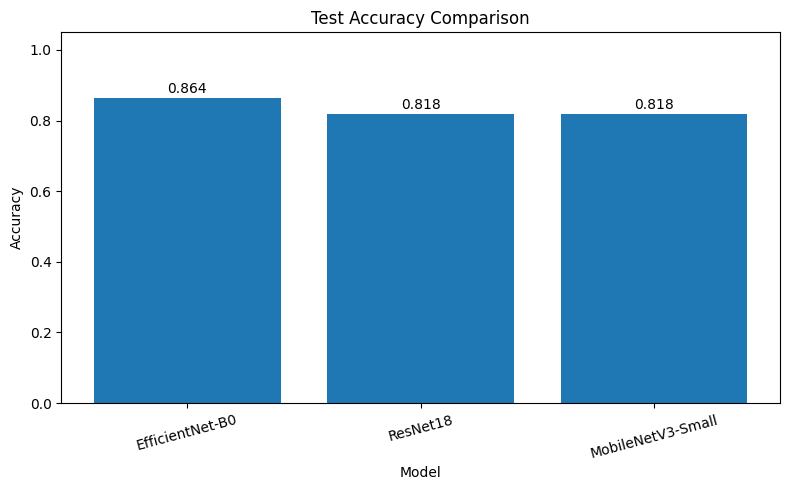

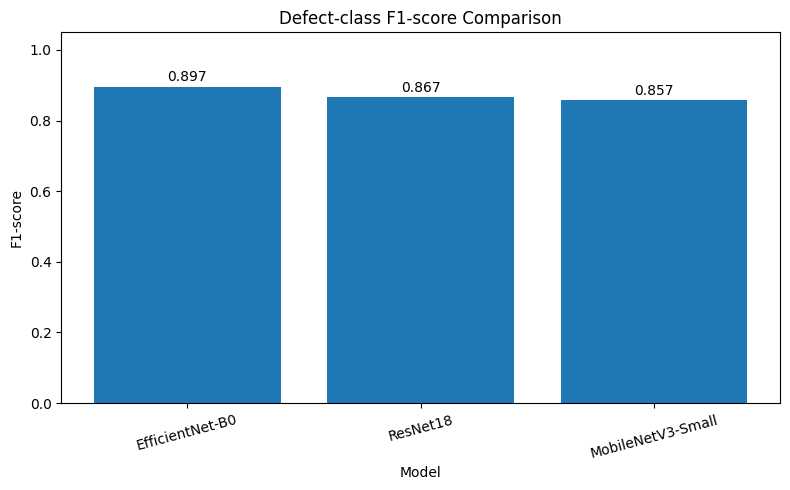

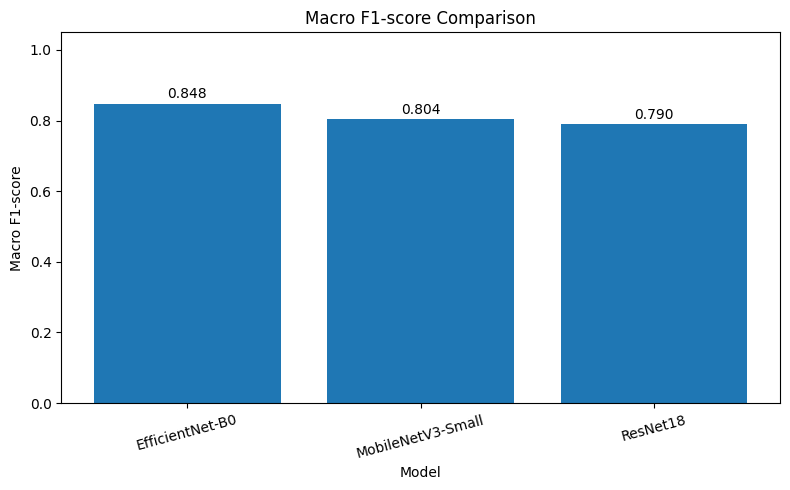

In [37]:
# ============================================================
# 15. Visual comparison of the main metrics
# ============================================================

def plot_metric_comparison(df, metric, title, ylabel):
    plot_df = df.sort_values(metric, ascending=False)

    plt.figure(figsize=(8, 5))
    bars = plt.bar(plot_df["model"], plot_df[metric])
    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(ylabel)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=15)

    for bar, value in zip(bars, plot_df[metric]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.015,
            f"{value:.3f}",
            ha="center"
        )

    plt.tight_layout()
    plt.show()


plot_metric_comparison(
    comparison_df,
    "accuracy",
    "Test Accuracy Comparison",
    "Accuracy"
)

plot_metric_comparison(
    comparison_df,
    "f1_defect",
    "Defect-class F1-score Comparison",
    "F1-score"
)

plot_metric_comparison(
    comparison_df,
    "macro_f1",
    "Macro F1-score Comparison",
    "Macro F1-score"
)


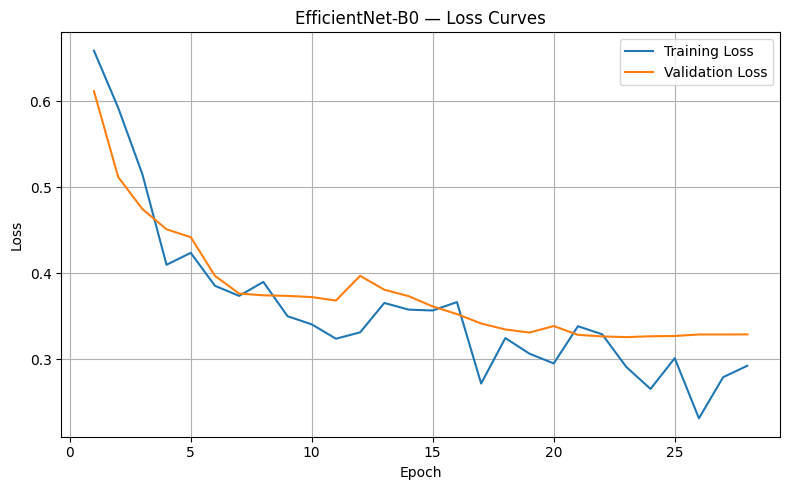

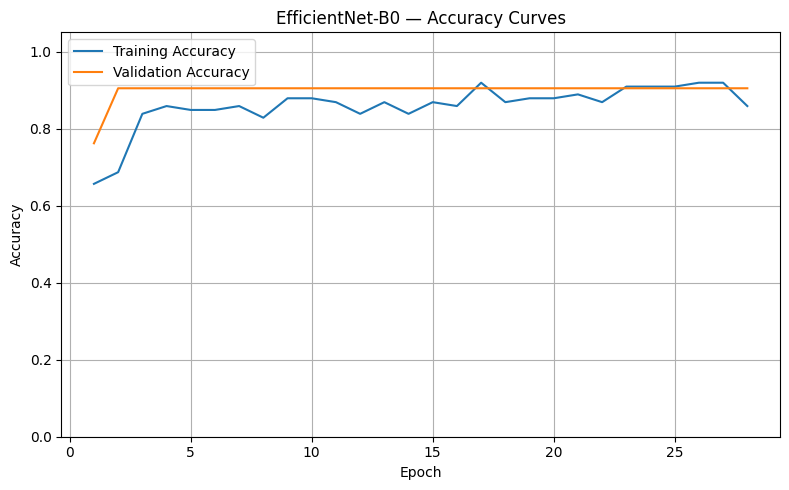

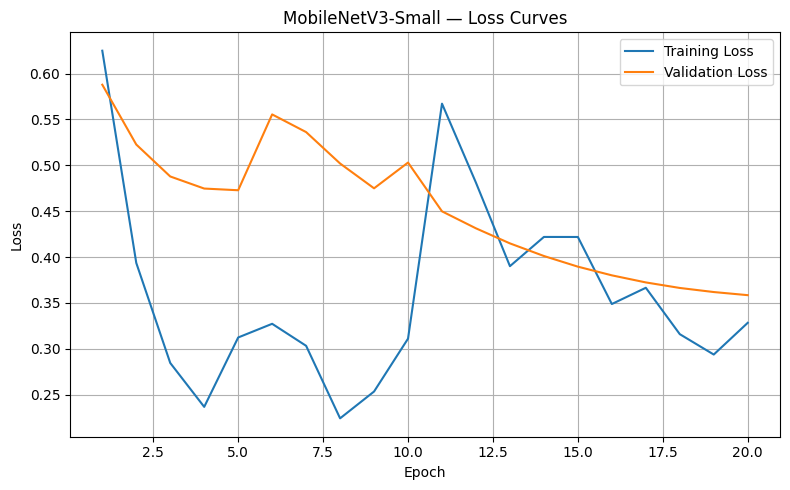

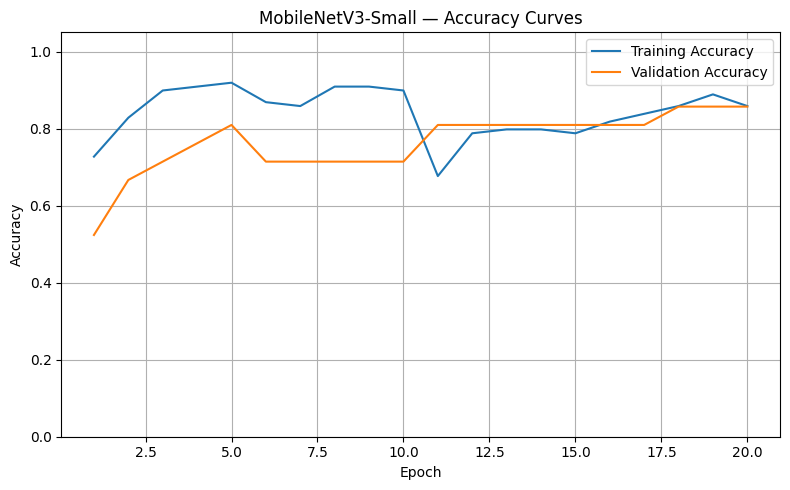

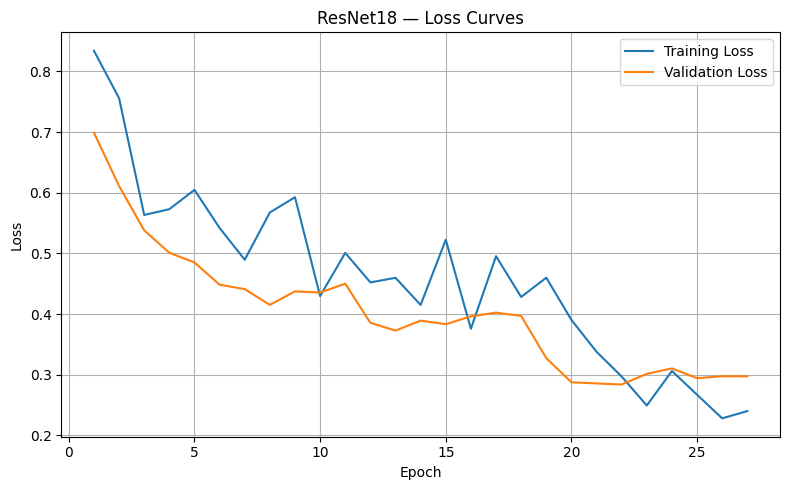

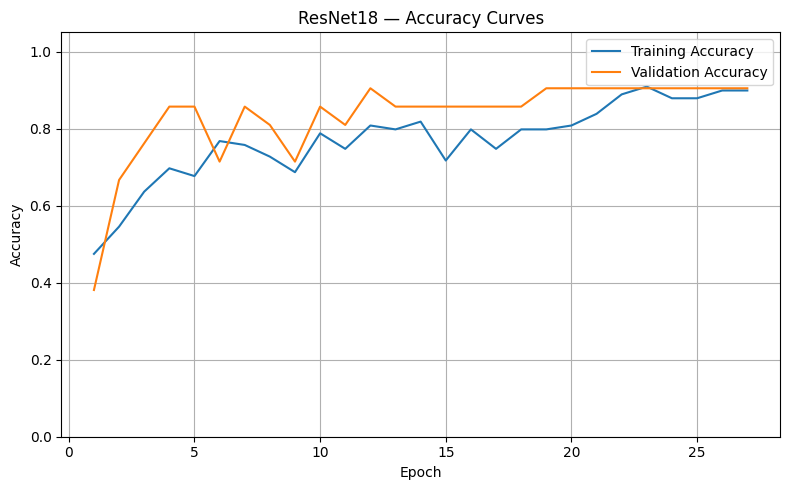

In [38]:
# ============================================================
# 16. Training curves for each model
# ============================================================

def plot_training_history(history, model_display_name):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Training Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.title(f"{model_display_name} — Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Training Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.title(f"{model_display_name} — Accuracy Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


for model_name in MODEL_NAMES:
    plot_training_history(
        model_details[model_name]["history"],
        MODEL_DISPLAY_NAMES[model_name]
    )



EfficientNet-B0
              precision    recall  f1-score   support

      Defect     0.8667    0.9286    0.8966        14
      Normal     0.8571    0.7500    0.8000         8

    accuracy                         0.8636        22
   macro avg     0.8619    0.8393    0.8483        22
weighted avg     0.8632    0.8636    0.8614        22



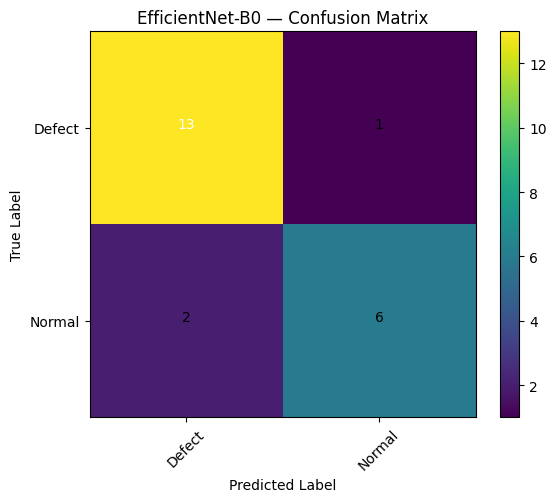


MobileNetV3-Small
              precision    recall  f1-score   support

      Defect     0.8571    0.8571    0.8571        14
      Normal     0.7500    0.7500    0.7500         8

    accuracy                         0.8182        22
   macro avg     0.8036    0.8036    0.8036        22
weighted avg     0.8182    0.8182    0.8182        22



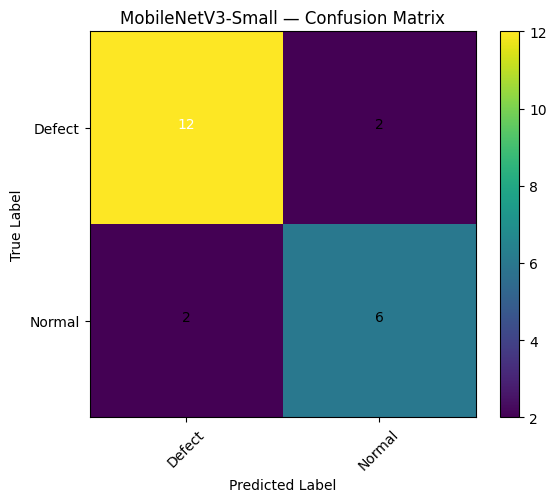


ResNet18
              precision    recall  f1-score   support

      Defect     0.8125    0.9286    0.8667        14
      Normal     0.8333    0.6250    0.7143         8

    accuracy                         0.8182        22
   macro avg     0.8229    0.7768    0.7905        22
weighted avg     0.8201    0.8182    0.8113        22



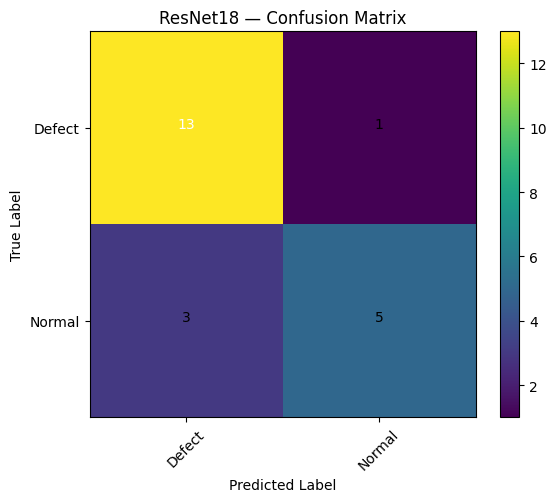

In [39]:
# ============================================================
# 17. Classification reports and confusion matrices
# ============================================================

def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    threshold = cm.max() / 2.0 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                format(cm[i, j], "d"),
                horizontalalignment="center",
                color="white" if cm[i, j] > threshold else "black"
            )

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()


for model_name in MODEL_NAMES:
    print("\n" + "=" * 70)
    print(MODEL_DISPLAY_NAMES[model_name])
    print("=" * 70)
    print(model_details[model_name]["classification_report"])

    plot_confusion_matrix(
        model_details[model_name]["confusion_matrix"],
        CLASS_NAMES,
        f"{MODEL_DISPLAY_NAMES[model_name]} — Confusion Matrix"
    )


In [40]:
# ============================================================
# 18. Select the best model and predict a single image
# ============================================================

best_row = comparison_df.iloc[0]
BEST_MODEL_NAME = best_row["model_key"]
BEST_MODEL_PATH = best_row["checkpoint_path"]

print("Best model based on Defect F1-score:", best_row["model"])
print(f"Defect F1-score: {best_row['f1_defect']:.4f}")
print("Checkpoint:", BEST_MODEL_PATH)


def get_inference_transform(img_size=224):
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])


@torch.no_grad()
def predict_single_image(image_path, model_path=BEST_MODEL_PATH):
    checkpoint = torch.load(model_path, map_location=device)
    class_names = checkpoint["class_names"]
    model_name = checkpoint["model_name"]
    img_size = checkpoint["img_size"]

    model = build_model(
        model_name=model_name,
        num_classes=len(class_names),
        freeze_backbone=False,
        pretrained=False
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image_tensor = get_inference_transform(img_size)(image).unsqueeze(0).to(device)

    probabilities = torch.softmax(model(image_tensor), dim=1)[0]
    predicted_idx = int(torch.argmax(probabilities).cpu().item())

    return {
        "image_path": image_path,
        "model": MODEL_DISPLAY_NAMES[model_name],
        "predicted_class": class_names[predicted_idx],
        "confidence": float(probabilities[predicted_idx].cpu().item()),
        "probabilities": {
            class_names[i]: float(probabilities[i].cpu().item())
            for i in range(len(class_names))
        }
    }


example_image_path = test_paths[0]
prediction_result = predict_single_image(example_image_path)
print("\nSingle-image prediction example:")
print(prediction_result)


Best model based on Defect F1-score: EfficientNet-B0
Defect F1-score: 0.8966
Checkpoint: /kaggle/working/leather_model_comparison/efficientnet_b0_best.pth

Single-image prediction example:
{'image_path': np.str_('/kaggle/input/datasets/eryuns/dataset-kulit-manding-yogya/Manding Leather Dataset/Defect/94F2C35F-0AE2-41CA-B32D-63ACEA2E7411_4_5005_c.jpeg'), 'model': 'EfficientNet-B0', 'predicted_class': 'Normal', 'confidence': 0.8158122897148132, 'probabilities': {'Defect': 0.184187650680542, 'Normal': 0.8158122897148132}}


## Cara membaca hasil

- **F1 Defect** menjadi metrik utama karena tujuan sistem adalah mendeteksi citra kulit yang cacat dan dataset sedikit tidak seimbang.
- **Recall Defect** menunjukkan proporsi citra cacat yang berhasil ditemukan. Nilai rendah berarti banyak defect terlewat sebagai normal.
- **Precision Defect** menunjukkan seberapa sering prediksi defect memang benar. Nilai rendah berarti terlalu banyak citra normal ditandai sebagai defect.
- **Macro F1** memberi bobot yang sama kepada kelas Defect dan Normal, sehingga berguna untuk menilai keseimbangan kinerja kedua kelas.
- Model terbaik dipilih berdasarkan **F1 Defect**, kemudian **Macro F1**, lalu **Accuracy** sebagai tie-breaker.

Karena test set berukuran kecil, hasil satu kali split dapat berfluktuasi. Untuk pelaporan ilmiah yang lebih kuat, eksperimen berikutnya sebaiknya memakai stratified k-fold cross-validation dan melaporkan mean ± standard deviation.


In [41]:
# ============================================================
# 19. Save the overall best model in .pkl format
# ============================================================

import pickle

FINAL_BEST_MODEL_PATH = "/kaggle/working/best_leather_defect_model.pkl"

# BEST_MODEL_PATH dan best_row diperoleh dari hasil perbandingan model
# pada cell sebelumnya.
if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(
        f"Checkpoint model terbaik tidak ditemukan: {BEST_MODEL_PATH}"
    )

# Muat checkpoint terbaik ke CPU agar lebih mudah digunakan kembali.
best_checkpoint = torch.load(BEST_MODEL_PATH, map_location="cpu")

# Tambahkan informasi hasil pemilihan model ke checkpoint final.
best_checkpoint["selection_metric"] = "f1_defect"
best_checkpoint["selection_metric_value"] = float(best_row["f1_defect"])
best_checkpoint["macro_f1"] = float(best_row["macro_f1"])
best_checkpoint["test_accuracy"] = float(best_row["accuracy"])
best_checkpoint["display_name"] = str(best_row["model"])

# Simpan dictionary checkpoint PyTorch sebagai file Pickle.
with open(FINAL_BEST_MODEL_PATH, "wb") as file:
    pickle.dump(best_checkpoint, file, protocol=pickle.HIGHEST_PROTOCOL)

file_size_mb = os.path.getsize(FINAL_BEST_MODEL_PATH) / (1024 ** 2)

print("=" * 65)
print("MODEL TERBAIK BERHASIL DISIMPAN DALAM FORMAT .PKL")
print("=" * 65)
print(f"Model              : {best_row['model']}")
print(f"F1-score Defect    : {best_row['f1_defect']:.4f}")
print(f"Macro F1           : {best_row['macro_f1']:.4f}")
print(f"Test Accuracy      : {best_row['accuracy']:.4f}")
print(f"Lokasi file        : {FINAL_BEST_MODEL_PATH}")
print(f"Ukuran file        : {file_size_mb:.2f} MB")


MODEL TERBAIK BERHASIL DISIMPAN DALAM FORMAT .PKL
Model              : EfficientNet-B0
F1-score Defect    : 0.8966
Macro F1           : 0.8483
Test Accuracy      : 0.8636
Lokasi file        : /kaggle/working/best_leather_defect_model.pkl
Ukuran file        : 15.58 MB
